In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Path to your event log CSV
log_path = "D:/Projects/Big/opra/data/logs/LoanApp/LoanApp.csv"

# Read log
df_log = pd.read_csv(log_path)

# Detect case id column
if "case_id" in df_log.columns:
    case_col = "case_id"
elif "case" in df_log.columns:
    case_col = "case"

else:
    raise ValueError("No case id column found. Expected 'caseid' or 'case'.")

# Group by case id (number of events per case)
cases_grouped = df_log.groupby(case_col).size().reset_index(name="num_events")

# Number of cases
num_cases = cases_grouped.shape[0]
print(f"Number of cases: {num_cases}")

# cases_grouped.head()

Number of cases: 1000


In [16]:
df_agents = pd.read_csv("./data/training_runs/AcademicCredentials_DDPS_p90_700_200/update_metrics.csv")

df_agents

,update,episode,policy_loss,value_loss,entropy,total_loss,approx_kl,clip_fraction
0,1,1,-0.064329,0.500777,4.980846,0.386640,NaN,NaN
1,2,2,-0.036747,0.498896,4.956758,0.412581,NaN,NaN
2,3,3,-0.014447,0.498591,4.985941,0.434285,NaN,NaN
3,4,4,0.003330,0.496750,4.952654,0.450554,NaN,NaN
4,5,5,0.014665,0.496852,4.976990,0.461747,NaN,NaN
...,...,...,...,...,...,...,...,...
195,196,196,0.006066,0.471691,4.159750,0.436160,NaN,NaN
196,197,197,-0.025107,0.456007,4.138437,0.389516,NaN,NaN
197,198,198,-0.016802,0.493023,4.134857,0.434872,NaN,NaN
198,199,199,0.016734,0.463799,4.127657,0.439256,NaN,NaN


In [17]:
df_episode = pd.read_csv("./data/training_runs/AcademicCredentials_DDPS_p90_700_200/episode_metrics.csv")

df_episode

,episode,total_reward,num_steps,num_cases,num_compliant,sla_compliance_rate,avg_cycle_time,median_cycle_time,std_cycle_time,min_cycle_time,max_cycle_time,p75_cycle_time,p90_cycle_time,p95_cycle_time,episode_duration_sec,resource_utilization_cv
0,1,728.710716,5119,700,694,0.991429,398369.267143,228967.5,421798.401356,676.0,1973201.0,626642.00,1005101.4,1332080.20,12.411295,NaN
1,2,735.428804,5220,700,696,0.994286,422490.101429,258986.0,434460.293830,370.0,2189534.0,657728.25,1056742.6,1365249.60,13.628627,NaN
2,3,730.820378,4931,700,695,0.992857,384611.708571,205726.5,427115.945798,1086.0,2309787.0,613911.75,1013235.2,1249028.00,12.094649,NaN
3,4,721.210763,4997,700,690,0.985714,396003.107143,224272.0,424769.147723,955.0,2002969.0,616946.75,974364.8,1337634.20,12.167663,NaN
4,5,723.916623,4850,700,694,0.991429,361402.668571,200537.5,408816.388199,1822.0,2570305.0,548115.50,932133.3,1153101.35,11.825987,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,714.458379,2158,700,700,1.000000,197007.485714,99254.0,224165.594005,312.0,1166519.0,258566.25,535083.3,658262.85,5.528842,NaN
196,197,714.460400,2159,700,700,1.000000,190402.301429,96191.5,225820.474569,401.0,1728257.0,248503.25,514798.9,633877.75,5.297564,NaN
197,198,714.337238,2147,700,700,1.000000,179647.454286,94520.0,206052.520708,1208.0,961183.0,236277.25,479929.1,633270.25,5.845958,NaN
198,199,712.394287,2154,700,699,0.998571,192458.182857,103557.5,225593.511895,590.0,1996280.0,245770.75,491947.6,637891.80,7.163530,NaN


In [18]:
df_episode.describe()

,episode,total_reward,num_steps,num_cases,num_compliant,sla_compliance_rate,avg_cycle_time,median_cycle_time,std_cycle_time,min_cycle_time,max_cycle_time,p75_cycle_time,p90_cycle_time,p95_cycle_time,episode_duration_sec,resource_utilization_cv
count,200.000000,200.000000,200.000000,200.0,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02,200.000000,2.000000e+02,2.000000e+02,200.000000,0.0
mean,100.500000,715.341547,2402.080000,700.0,699.330000,0.999043,209619.692129,108564.267500,242318.868254,579.885000,1.390677e+06,281299.972500,5.698184e+05,7.284329e+05,7.094338,NaN
std,57.879185,3.934080,732.505094,0.0,1.765413,0.002522,56808.491253,33466.846598,59923.317211,347.064129,4.704473e+05,104671.728952,1.391810e+05,1.823058e+05,8.494784,NaN
min,1.000000,710.721074,2104.000000,700.0,690.000000,0.985714,168909.380000,81836.000000,196951.735874,111.000000,9.583710e+05,213533.000000,4.204348e+05,6.082201e+05,4.944731,NaN
25%,50.750000,714.062843,2122.000000,700.0,700.000000,1.000000,183856.936429,93716.750000,213824.919403,329.750000,9.833442e+05,232672.625000,5.047798e+05,6.357606e+05,5.218898,NaN
50%,100.500000,714.191986,2136.000000,700.0,700.000000,1.000000,190501.180714,99334.750000,221622.732596,497.500000,1.201992e+06,241784.000000,5.277547e+05,6.495693e+05,6.013444,NaN
75%,150.250000,714.411881,2157.250000,700.0,700.000000,1.000000,198634.364643,102289.375000,230770.943766,727.000000,1.712887e+06,263173.187500,5.870472e+05,6.954524e+05,6.835500,NaN
max,200.000000,735.428804,5220.000000,700.0,700.000000,1.000000,422490.101429,258986.000000,442372.663811,1822.000000,2.641026e+06,657728.250000,1.056743e+06,1.405647e+06,123.616584,NaN


C:\Users\david\AppData\Local\Temp\ipykernel_23152\2815139290.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


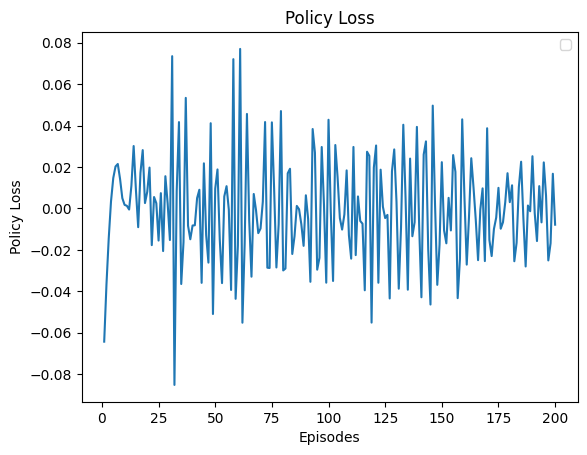

In [19]:
plt.plot(df_agents["episode"], df_agents['policy_loss'])
plt.xlabel("Episodes")
plt.ylabel("Policy Loss")
plt.title("Policy Loss")
plt.legend()
plt.show()

C:\Users\david\AppData\Local\Temp\ipykernel_23152\1478400342.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


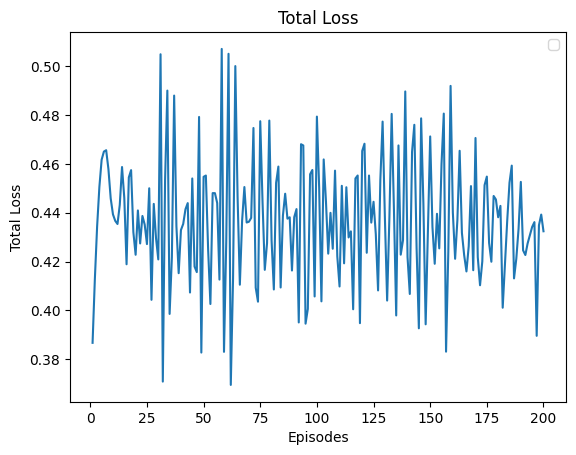

In [20]:
plt.plot(df_agents["episode"], df_agents['total_loss'])
plt.xlabel("Episodes")
plt.ylabel("Total Loss")
plt.title("Total Loss")
plt.legend()
plt.show()

C:\Users\david\AppData\Local\Temp\ipykernel_23152\1471025587.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


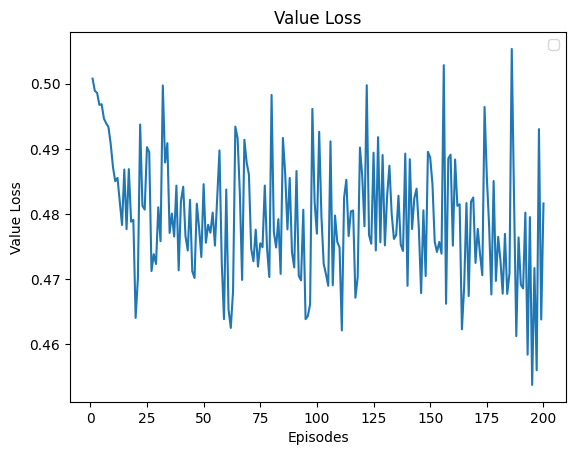

In [21]:
plt.plot(df_agents["episode"], df_agents['value_loss'])
plt.xlabel("Episodes")
plt.ylabel("Value Loss")
plt.title("Value Loss")
plt.legend()
plt.show()

C:\Users\david\AppData\Local\Temp\ipykernel_23152\2094019363.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


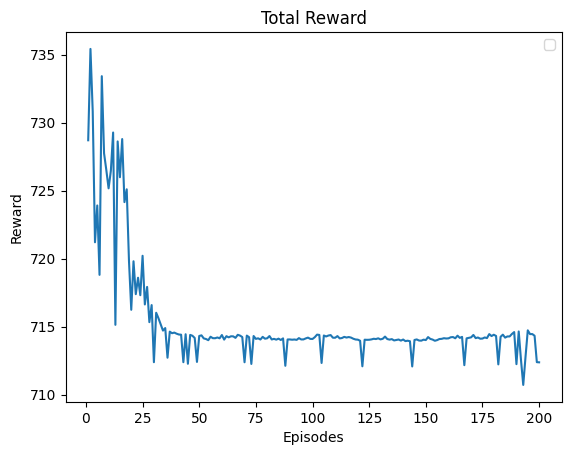

In [22]:
plt.plot(df_episode["episode"], df_episode['total_reward'])
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Total Reward")
plt.legend()
plt.show()